In [2]:
pip install gensim


   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   - -------------------------------------- 0.8/24.4 MB 2.1 MB/s eta 0:00:12
   -- ------------------------------------- 1.3/24.4 MB 2.1 MB/s eta 0:00:12
   -- ------------------------------------- 1.6/24.4 MB 2.2 MB/s eta 0:00:11
   --- ------------------------------------ 2.1/24.4 MB 2.3 MB/s eta 0:00:10
   --- ------------------------------------ 2.4/24.4 MB 2.2 MB/s eta 0:00:10
   ----- ---------------------------------- 3.1/24.4 MB 2.2 MB/s eta 0:00:10
   ----- ---------------------------------- 3.4/24.4 MB 2.2 MB/s eta 0:00:10
   ------ --------------------------------- 3.7/24.4 MB 2.1 MB/s eta 0:00:10
   ------ --------------------------------- 3.7/24.4 MB 2.1 MB/s eta 0:00:10
   ------ --------------------------------- 4.2/24.4 MB 1.9 MB/s eta 0:00:11
   ------- -------------------------------- 4.5/24.4 MB 1.9 MB/s eta 0:00:11
   -------- 

In [4]:
import pandas as pd
import numpy as np
import re

from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from gensim.models import Word2Vec

In [5]:
df = pd.read_csv(
    "dataset_detik.csv",
    sep=";",
    encoding="utf-8-sig"
)

print("Jumlah data:", len(df))
print(df.head())

Jumlah data: 200
   id                                         isi_berita  label
0   1  Ciamis - Sebanyak 549 siswa dari 40 SD mengiku...  sport
1   2  Dalam dua seri terakhir MotoGP 2027, Marc Marq...  sport
2   3  Alwi Farhan, Moh Zaki Ubaidillah dan Muhamad Y...  sport
3   4  Di tengah viral insiden cepirit pada ajang Hyr...  sport
4   5  Dejan Fedinansyah/Felisha Alberta Nathaniel Pa...  sport


In [6]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
stop_words = set(stopwords.words("indonesian"))

factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [ ]:
#Prepocessing Menghapus angka

In [8]:
def preprocessing_angka(teks):
    # lowercase
    teks = teks.lower()

    # hapus URL
    teks = re.sub(r"http\S+|www\S+", "", teks)

    # HANYA hapus angka
    teks = re.sub(r"\d+", " ", teks)

    # rapikan spasi
    teks = re.sub(r"\s+", " ", teks).strip()

    # tokenisasi
    tokens = teks.split()

    # stopword removal
    tokens = [
        kata for kata in tokens
        if kata not in stop_words
    ]

    # stemming
    tokens = [
        stemmer.stem(kata)
        for kata in tokens
    ]

    return tokens

In [9]:
df["tokens_angka"] = df["isi_berita"].apply(preprocessing_angka)

In [10]:
display(df[["id", "tokens_angka", "label"]].head())

,id,tokens_angka,label
0,1,"[ciamis, -, siswa, sd, ikut, lomba, olahraga, ...",sport
1,2,"[seri, motogp, , marc, marquez, sukses, sapu, ...",sport
2,3,"[alwi, farhan, moh, zaki, ubaidillah, muhamad,...",sport
3,4,"[viral, insiden, cepirit, ajang, hyrox, atlet,...",sport
4,5,"[dejan, fedinansyah felisha, alberta, nathanie...",sport


In [ ]:
#Word_Embedding Menggunakan SkipGram

In [18]:
from gensim.models import Word2Vec

model_angka = Word2Vec(
    sentences=df["tokens_angka"].tolist(),
    vector_size=5,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    seed=42
)

In [12]:
print("Jumlah vocabulary:", len(model_angka.wv.index_to_key))

Jumlah vocabulary: 5309


In [13]:
print(model_angka.wv.index_to_key[:20])

['', 'indonesia', '-', 'jakarta', 'menteri', 'rp', 'balap', 'uang', 'motogp', 'ini', 'marquez', 'emas', 'jalan', 'hasil', 'usaha', 'juara', 'posisi', 'sebut', 'kembang', 'poin']


In [19]:
for kata in model_angka.wv.index_to_key:
    print(kata, "=", model_angka.wv[kata])

 = [-2.1755636   0.65117395 -0.4293225   1.116678    1.1564447 ]
indonesia = [-0.34254035 -1.602258   -0.88833874  0.35238996  0.8424775 ]
- = [-1.9547579  0.3119961 -0.6314602  1.0193145  0.7494377]
jakarta = [ 0.34292603 -0.4537645  -0.5413162   2.6829417   1.0153267 ]
menteri = [ 0.08088512  0.66433626 -0.5538348   1.2685287   2.3665748 ]
rp = [-2.0056608  -0.87786335  0.98862344  0.8608155   1.6922219 ]
balap = [-1.2158265  -0.09325518 -2.3289742   0.15216717  0.43853718]
uang = [-0.14321902  0.64386344 -0.38778764  0.8965332   2.438274  ]
motogp = [-2.2069073  -0.088168   -2.2523189  -0.17307656  0.647656  ]
ini = [-0.605517   -0.6288354  -0.8856266   0.57122827  0.7378732 ]
marquez = [-1.9665798  -0.05374314 -2.8203843   0.9286387   0.13168123]
emas = [-1.7380614  -1.7193379   0.11944084  0.80365795  0.6621772 ]
jalan = [-2.70252931e-04 -8.57277632e-01 -1.26896489e+00  1.23379454e-01
  1.08702731e+00]
hasil = [-1.1618787  -0.87077403 -1.3953487  -0.23910679  0.52653605]
usaha = [

In [20]:
import numpy as np

def document_vector(tokens, model):
    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [21]:
vsm_angka = np.array([
    document_vector(tokens, model_angka)
    for tokens in df["tokens_angka"]
])

In [22]:
print(vsm_angka.shape)

(200, 5)


In [24]:
vsm_angka_df = pd.DataFrame(
    vsm_angka,
    columns=[f"vector_{i+1}" for i in range(5)]
)

vsm_angka_df.insert(0, "id", df["id"].values)
vsm_angka_df["label"] = df["label"].values

In [25]:
display(vsm_angka_df.head())

,id,vector_1,vector_2,vector_3,vector_4,vector_5,label
0,1,-0.456126,-0.581880,-0.614442,0.467987,0.852776,sport
1,2,-1.017350,-0.350829,-1.548920,0.432442,0.569120,sport
2,3,-0.729524,-0.868121,-0.583045,0.520767,0.814154,sport
3,4,-0.534134,-0.437685,-0.723167,0.411028,0.782400,sport
4,5,-0.762059,-1.025054,-0.536793,0.597082,0.784384,sport


In [26]:
vsm_angka_df.to_csv(
    "hasil_vsm_hapus_angka.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
#Pemodelan

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

In [29]:
X = vsm_angka_df[["vector_1", "vector_2", "vector_3", "vector_4", "vector_5"]]
y = vsm_angka_df["label"]

In [30]:
print(X.shape)
print(y.shape)

(200, 5)
(200,)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
print("Data training :", X_train.shape)
print("Data testing  :", X_test.shape)

Data training : (160, 5)
Data testing  : (40, 5)


In [33]:
nb = GaussianNB()

nb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [35]:
y_pred = nb.predict(X_test)

In [36]:
print(y_pred)

['finance' 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport'
 'sport' 'finance' 'sport' 'sport' 'finance' 'sport' 'finance' 'finance'
 'sport' 'sport' 'finance' 'sport' 'finance' 'sport' 'sport' 'sport'
 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport' 'finance'
 'finance' 'finance' 'finance' 'finance' 'finance' 'sport' 'sport'
 'finance']


In [ ]:
#Evaluasi

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [38]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.95
Precision: 0.9545454545454545
Recall   : 0.95
F1-Score : 0.949874686716792


In [39]:
print("Accuracy :", accuracy * 100, "%")
print("Precision:", precision * 100, "%")
print("Recall   :", recall * 100, "%")
print("F1-Score :", f1 * 100, "%")

Accuracy : 95.0 %
Precision: 95.45454545454545 %
Recall   : 95.0 %
F1-Score : 94.9874686716792 %


In [40]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[18  2]
 [ 0 20]]


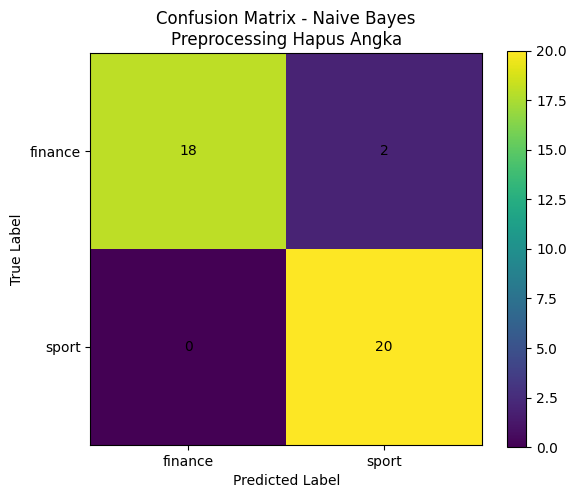

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Naive Bayes\nPreprocessing Hapus Angka")
plt.colorbar()

kelas = nb.classes_
plt.xticks(range(len(kelas)), kelas)
plt.yticks(range(len(kelas)), kelas)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Menampilkan angka di dalam kotak
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.tight_layout()
plt.show()

In [ ]:
#Prepocessing menghapus tanda baca

In [43]:
def preprocessing_tanda_baca(teks):
    teks = teks.lower()

    # Menghapus URL
    teks = re.sub(r"http\S+|www\S+", "", teks)

    # Menghapus tanda baca saja
    # Angka tetap dipertahankan
    teks = re.sub(r"[^\w\s]", " ", teks)

    # Menghilangkan spasi berlebih
    teks = re.sub(r"\s+", " ", teks).strip()

    # Tokenisasi
    tokens = teks.split()

    # Stopword
    tokens = [kata for kata in tokens if kata not in stop_words]

    # Stemming
    tokens = [stemmer.stem(kata) for kata in tokens]

    return tokens

In [44]:
df["tokens_tanda_baca"] = df["isi_berita"].apply(
    preprocessing_tanda_baca
)

In [45]:
display(df[["id", "tokens_tanda_baca", "label"]].head())

,id,tokens_tanda_baca,label
0,1,"[ciamis, 549, siswa, 40, sd, ikut, lomba, olah...",sport
1,2,"[seri, motogp, 2027, marc, marquez, sukses, sa...",sport
2,3,"[alwi, farhan, moh, zaki, ubaidillah, muhamad,...",sport
3,4,"[viral, insiden, cepirit, ajang, hyrox, atlet,...",sport
4,5,"[dejan, fedinansyah, felisha, alberta, nathani...",sport


In [ ]:
#Word EMbedding

In [46]:
from gensim.models import Word2Vec

model_tanda = Word2Vec(
    sentences=df["tokens_tanda_baca"].tolist(),
    vector_size=5,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    seed=42
)

In [47]:
print("Jumlah vocabulary:", len(model_tanda.wv.index_to_key))

Jumlah vocabulary: 5620


In [49]:
for kata in model_tanda.wv.index_to_key:
    print(kata, "=", model_tanda.wv[kata])

2026 = [-0.48227775  0.32653338  0.43368235  0.21461253  2.2754524 ]
indonesia = [ 1.128589   -0.02670704  0.40919104 -0.15225734  1.6841521 ]
9 = [-1.0498242   0.8346971  -0.5891799   0.44087175  2.3553953 ]
jakarta = [ 0.46655673  2.1824088  -0.67705244  0.1657791   2.0717773 ]
menteri = [ 0.8966865  0.6906032 -2.508008   0.2707295  1.1998731]
1 = [-0.91305053 -0.18658188 -0.61247325 -0.8606686   2.0243852 ]
balap = [ 0.3979421  -1.8198828  -0.6407291  -0.19402842  2.0063074 ]
uang = [ 0.7676946   0.80168194 -2.3512526  -0.12834069  1.1511961 ]
motogp = [-0.2714567  -1.7264111  -0.33036393 -0.17911465  2.6054304 ]
jalan = [ 1.3014834  -0.28674287 -0.17661634  0.678308    1.4854482 ]
usaha = [ 2.0773025  -0.14064156 -0.9320691   0.10766184  1.068156  ]
hasil = [ 0.55160695 -0.94656515  0.01432763 -0.05135617  1.6986936 ]
marquez = [-0.09948647 -2.1302266  -1.3389144   0.10711945  2.5971498 ]
emas = [ 0.2598917   0.7334984   0.23016244 -2.1843069   1.7618515 ]
juara = [ 0.7376277 -1.15

In [50]:
import numpy as np

def document_vector(tokens, model):
    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [51]:
vsm_tanda = np.array([
    document_vector(tokens, model_tanda)
    for tokens in df["tokens_tanda_baca"]
])

In [52]:
print(vsm_tanda.shape)

(200, 5)


In [53]:
vsm_tanda_df = pd.DataFrame(
    vsm_tanda,
    columns=["V1", "V2", "V3", "V4", "V5"]
)

vsm_tanda_df.insert(0, "id", df["id"].values)
vsm_tanda_df["label"] = df["label"].values

display(vsm_tanda_df.head())

,id,V1,V2,V3,V4,V5,label
0,1,0.599721,0.102523,-0.171356,-0.173033,1.225070,sport
1,2,0.251108,-0.921149,-0.515851,-0.186562,1.735410,sport
2,3,0.586802,0.064210,0.185218,-0.315428,1.614513,sport
3,4,0.451997,-0.015034,-0.313269,-0.229144,1.184643,sport
4,5,0.690775,0.055491,0.385876,-0.404717,1.756999,sport


In [54]:
vsm_tanda_df.to_csv(
    "hasil_vsm_hapus_tanda_baca.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
#Pemodelan

In [55]:
X_tanda = vsm_tanda_df[["V1", "V2", "V3", "V4", "V5"]]
y_tanda = vsm_tanda_df["label"]

In [56]:
print("X:", X_tanda.shape)
print("y:", y_tanda.shape)

X: (200, 5)
y: (200,)


In [57]:
from sklearn.model_selection import train_test_split

X_train_tanda, X_test_tanda, y_train_tanda, y_test_tanda = train_test_split(
    X_tanda,
    y_tanda,
    test_size=0.2,
    random_state=42,
    stratify=y_tanda
)

In [58]:
print("Data training :", X_train_tanda.shape)
print("Data testing  :", X_test_tanda.shape)

Data training : (160, 5)
Data testing  : (40, 5)


In [59]:
from sklearn.naive_bayes import GaussianNB

nb_tanda = GaussianNB()

In [60]:
nb_tanda.fit(X_train_tanda, y_train_tanda)

,priors,None
,var_smoothing,1e-09


In [61]:
y_pred_tanda = nb_tanda.predict(X_test_tanda)

In [62]:
print(y_pred_tanda)

['finance' 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport'
 'sport' 'finance' 'sport' 'sport' 'finance' 'sport' 'finance' 'finance'
 'sport' 'sport' 'finance' 'sport' 'finance' 'sport' 'sport' 'finance'
 'sport' 'sport' 'finance' 'finance' 'sport' 'finance' 'sport' 'finance'
 'finance' 'finance' 'finance' 'finance' 'finance' 'sport' 'sport'
 'finance']


In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_tanda = accuracy_score(y_test_tanda, y_pred_tanda)

precision_tanda = precision_score(
    y_test_tanda,
    y_pred_tanda,
    average="weighted",
    zero_division=0
)

recall_tanda = recall_score(
    y_test_tanda,
    y_pred_tanda,
    average="weighted",
    zero_division=0
)

f1_tanda = f1_score(
    y_test_tanda,
    y_pred_tanda,
    average="weighted",
    zero_division=0
)

print("Accuracy :", accuracy_tanda)
print("Precision:", precision_tanda)
print("Recall   :", recall_tanda)
print("F1-Score :", f1_tanda)

Accuracy : 0.9
Precision: 0.9
Recall   : 0.9
F1-Score : 0.9


In [64]:
print("Accuracy :", accuracy_tanda * 100, "%")
print("Precision:", precision_tanda * 100, "%")
print("Recall   :", recall_tanda * 100, "%")
print("F1-Score :", f1_tanda * 100, "%")

Accuracy : 90.0 %
Precision: 90.0 %
Recall   : 90.0 %
F1-Score : 90.0 %


In [65]:
from sklearn.metrics import confusion_matrix

cm_tanda = confusion_matrix(
    y_test_tanda,
    y_pred_tanda
)

print(cm_tanda)
print("Urutan kelas:", nb_tanda.classes_)

[[18  2]
 [ 2 18]]
Urutan kelas: ['finance' 'sport']


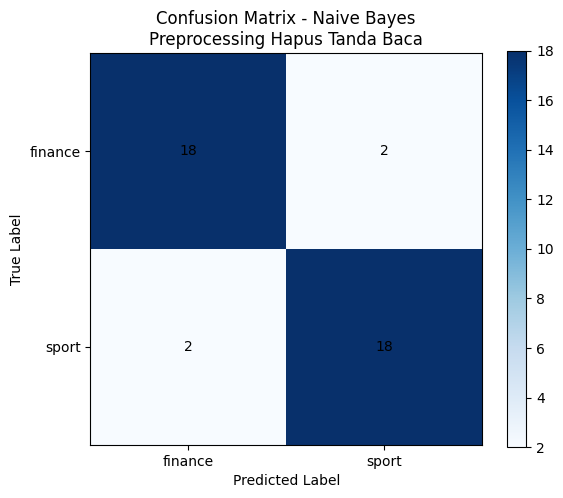

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(
    cm_tanda,
    interpolation="nearest",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix - Naive Bayes\n"
    "Preprocessing Hapus Tanda Baca"
)

plt.colorbar()

kelas = nb_tanda.classes_

plt.xticks(
    range(len(kelas)),
    kelas
)

plt.yticks(
    range(len(kelas)),
    kelas
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm_tanda.shape[0]):
    for j in range(cm_tanda.shape[1]):
        plt.text(
            j,
            i,
            cm_tanda[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [67]:
hasil_perbandingan = pd.DataFrame({
    "Preprocessing": [
        "Hapus Angka",
        "Hapus Tanda Baca"
    ],
    "Accuracy": [
        accuracy,
        accuracy_tanda
    ],
    "Precision": [
        precision,
        precision_tanda
    ],
    "Recall": [
        recall,
        recall_tanda
    ],
    "F1-Score": [
        f1,
        f1_tanda
    ]
})

display(hasil_perbandingan)

,Preprocessing,Accuracy,Precision,Recall,F1-Score
0,Hapus Angka,0.95,0.954545,0.95,0.949875
1,Hapus Tanda Baca,0.90,0.900000,0.90,0.900000
